<a href="https://colab.research.google.com/github/riyaislamshanta482-ctrl/Aissinment-5/blob/main/Assinment5_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 05 - Feature Engineering & Regression Modeling
Dataset: student_dataset_dirty.csv

This notebook covers:

Part A: Data Cleaning

Part B: Feature Engineering

Part C: Linear Regression (predict Total_Score)

Part D: Logistic Regression (predict Result)

This is a basic starter template. Fill in the TODOs, add your own analysis, plots, and explanations.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay
)

pd.set_option('display.max_columns', None)



****


## Part A — Data Cleaning & Preparation

****

In [ ]:
import pandas as pd
df = pd.read_csv("/content/student_dataset_dirty - student_dataset_dirty.csv")
df1=df.copy()
df1


,Student_ID,Name,Age,Gender,City,Class,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score,Parent_Education,Internet_Access,Result
0,1978,Bristi Khan,16,MALE,Mymensingh,Eight,77.0,2.6,83,62,68,213,PRIMARY,no,FAIL
1,3881,hasan akter,12,F,Dhaka,10th,88.5,3.8,45,56,92,193,Secondary,NO,fail
2,53,Sohan Talukder,14,Male,Khulna,7th,65.1,3.6,37,82,89,208,NaN,NO,fail
3,2552,Mitu Hossain,11,FEMALE,Rajshahi,Ten,82.8,4.2,83,96,59,238,illiterate,N,PASS
4,2247,Ayesha Ahmed,14,other,KHULNA,9th,94.2,1.4,81,36,48,165,primary,0,pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,920,Rafi Hossain,15,NaN,Dacca,6,82.0,2.6,81,48,73,202,secondary,No,pass
9996,4308,Mim Akter,11,male,barisal,9,90.7,5.4,77,92,67,236,Graduate,no,Fail
9997,5700,Tamim Rahman,-18,O,Chittagong,Nine,87.6,1.5,53,72,61,186,illiterate,NaN,PASS
9998,538,Farhan Rahman,18,female,Chattogram,6,91.5,1.3,56,83,79,218,PRIMARY,yes,NaN


In [ ]:
#Shape
df1.shape

(10000, 15)

In [ ]:
#head
df1.head()

,Student_ID,Name,Age,Gender,City,Class,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score,Parent_Education,Internet_Access,Result
0,1978,Bristi Khan,16,MALE,Mymensingh,Eight,77.0,2.6,83,62,68,213,PRIMARY,no,FAIL
1,3881,hasan akter,12,F,Dhaka,10th,88.5,3.8,45,56,92,193,Secondary,NO,fail
2,53,Sohan Talukder,14,Male,Khulna,7th,65.1,3.6,37,82,89,208,NaN,NO,fail
3,2552,Mitu Hossain,11,FEMALE,Rajshahi,Ten,82.8,4.2,83,96,59,238,illiterate,N,PASS
4,2247,Ayesha Ahmed,14,other,KHULNA,9th,94.2,1.4,81,36,48,165,primary,0,pass


In [ ]:
df1.tail()

,Student_ID,Name,Age,Gender,City,Class,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score,Parent_Education,Internet_Access,Result
9995,920,Rafi Hossain,15,NaN,Dacca,6,82.0,2.6,81,48,73,202,secondary,No,pass
9996,4308,Mim Akter,11,male,barisal,9,90.7,5.4,77,92,67,236,Graduate,no,Fail
9997,5700,Tamim Rahman,-18,O,Chittagong,Nine,87.6,1.5,53,72,61,186,illiterate,NaN,PASS
9998,538,Farhan Rahman,18,female,Chattogram,6,91.5,1.3,56,83,79,218,PRIMARY,yes,NaN
9999,9413,Ayesha Chowdhury,17,O,rangpur,9,87.6,4.3,absent,43,73,116,Secondary,NaN,P


In [ ]:
#infro
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  object 
 1   Name                   9958 non-null   object 
 2   Age                    9804 non-null   object 
 3   Gender                 9162 non-null   object 
 4   City                   9775 non-null   object 
 5   Class                  10000 non-null  object 
 6   Attendance_Percentage  9745 non-null   float64
 7   Study_Hours_per_day    9803 non-null   float64
 8   Math_Score             9805 non-null   object 
 9   Science_Score          9800 non-null   object 
 10  English_Score          9804 non-null   object 
 11  Total_Score            9684 non-null   object 
 12  Parent_Education       8900 non-null   object 
 13  Internet_Access        8354 non-null   object 
 14  Result                 8906 non-null   object 
dtypes: 

In [ ]:
#describe()
df1.describe()

,Attendance_Percentage,Study_Hours_per_day
count,9745.000000,9803.000000
mean,84.708897,3.200857
std,18.511125,2.800264
min,-49.400000,-5.000000
25%,78.000000,2.000000
50%,84.800000,3.000000
75%,91.800000,4.100000
max,247.700000,29.900000


In [ ]:
#Missing value each column
df1.isnull().sum()

,0
Student_ID,0
Name,42
Age,196
Gender,838
City,225
Class,0
Attendance_Percentage,255
Study_Hours_per_day,197
Math_Score,195
Science_Score,200


In [ ]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())
# Drop duplicated values
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Duplicate rows: 150
Shape after dropping duplicates: (9850, 15)


In [ ]:
# datatype
df1.dtypes

,0
Student_ID,object
Name,object
Age,object
Gender,object
City,object
Class,object
Attendance_Percentage,float64
Study_Hours_per_day,float64
Math_Score,object
Science_Score,object


In [ ]:
# covert string to numerical value
df1["Age"] = pd.to_numeric(df1["Age"], errors="coerce")
df1["Total_Score"] = pd.to_numeric(df1["Total_Score"], errors="coerce")
df1["Math_Score"] = pd.to_numeric(df1["Math_Score"], errors = "coerce")
df1["Science_Score"] = pd.to_numeric(df1["Science_Score"],errors ="coerce")
df1["English_Score"] = pd.to_numeric(df1["English_Score"],errors ="coerce")

In [ ]:
df1.isnull().sum()

,0
Student_ID,0
Name,42
Age,303
Gender,838
City,225
Class,0
Attendance_Percentage,255
Study_Hours_per_day,197
Math_Score,245
Science_Score,237


In [ ]:
# describe
df1.describe()

,Age,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score
count,9697.000000,9745.000000,9803.000000,9755.000000,9763.000000,9763.000000,9599.000000
mean,16.426214,84.708897,3.200857,65.508970,64.807744,64.739834,190.538077
std,21.306011,18.511125,2.800264,27.435073,26.879069,26.180741,49.383933
min,-19.000000,-49.400000,-5.000000,-49.000000,-49.000000,-49.000000,-13.000000
25%,13.000000,78.000000,2.000000,47.000000,47.000000,47.000000,161.000000
50%,15.000000,84.800000,3.000000,65.000000,64.000000,64.000000,190.000000
75%,17.000000,91.800000,4.100000,83.000000,82.000000,82.000000,218.000000
max,298.000000,247.700000,29.900000,298.000000,299.000000,298.000000,517.000000


In [ ]:
# Handle outliers / invalid ranges (basic capping example — adjust as needed)
import numpy as np
df1.loc[(df1['Age'] < 5) | (df1['Age'] > 25), 'Age'] = np.nan
df1["Age"].describe()
df1["Age"].value_counts()

,count
Age,
17.0,1253
18.0,1213
15.0,1199
14.0,1193
16.0,1190
13.0,1184
11.0,1164
12.0,1110


In [ ]:
#describe Attendance_Percentage
df1["Attendance_Percentage"].describe()

,Attendance_Percentage
count,9745.000000
mean,84.708897
std,18.511125
min,-49.400000
25%,78.000000
50%,84.800000
75%,91.800000
max,247.700000


In [ ]:
#Attendance_Percentage value count
df1["Attendance_Percentage"].value_counts()

,count
Attendance_Percentage,
84.4,64
83.9,51
86.5,49
86.2,48
83.8,48
...,...
58.4,1
-36.9,1
-35.2,1


In [ ]:
df1.loc[(df1["Attendance_Percentage"]< 0) | (df1["Attendance_Percentage"] > 100)] = np.nan
df1["Attendance_Percentage"].describe()

,Attendance_Percentage
count,8858.000000
mean,83.577704
std,8.628562
min,45.400000
25%,77.700000
50%,84.000000
75%,90.000000
max,100.000000


In [ ]:
df1.loc[(df1['Study_Hours_per_day'] < 0) | (df1['Study_Hours_per_day'] > 16)] = np.nan
df1["Study_Hours_per_day"].describe()

,Study_Hours_per_day
count,8568.000000
mean,3.099510
std,1.422042
min,0.000000
25%,2.100000
50%,3.000000
75%,4.100000
max,9.700000


In [ ]:
#	Math_Score describe
df1["Math_Score"].describe()

,Math_Score
count,8533.000000
mean,65.525841
std,27.462611
min,-49.000000
25%,47.000000
50%,65.000000
75%,83.000000
max,298.000000


In [ ]:
df1.loc[(df1["Math_Score"] < 0) | (df1["Math_Score"] > 100)] = np.nan
df1['Math_Score'].describe()

,Math_Score
count,8353.000000
mean,64.773495
std,20.349724
min,30.000000
25%,47.000000
50%,65.000000
75%,83.000000
max,99.000000


In [ ]:
df1["English_Score"].describe()

,English_Score
count,8357.000000
mean,64.549001
std,26.447540
min,-49.000000
25%,46.000000
50%,64.000000
75%,82.000000
max,298.000000


In [ ]:
df1.loc[(df1["English_Score"] < 0) | (df1["English_Score"] > 100)] = np.nan
df1["English_Score"].describe()

,English_Score
count,8184.000000
mean,64.083578
std,20.088716
min,30.000000
25%,47.000000
50%,64.000000
75%,81.000000
max,99.000000


In [ ]:
#'Science_Score describe
df1["Science_Score"].describe()

,Science_Score
count,8195.000000
mean,64.636364
std,26.843607
min,-49.000000
25%,46.000000
50%,64.000000
75%,82.000000
max,299.000000


In [ ]:
# Handle missing values
# Numeric -> median imputation
df1["Age"] = df1["Age"].fillna(df1["Age"].median())
df1["Attendance_Percentage"] = df1["Attendance_Percentage"].fillna(df1["Attendance_Percentage"].median())
df1["Total_Score"] = df1["Total_Score"].fillna(df1["Total_Score"].median())
df1["Math_Score"] = df1["Math_Score"].fillna(df1["Math_Score"].median())
df1["Science_Score"] = df1["Science_Score"].fillna(df1["Science_Score"].median())
df1["English_Score"] = df1["English_Score"].fillna(df1["English_Score"].median())
df1["Study_Hours_per_day"] = df1["Study_Hours_per_day"].fillna(df1["Study_Hours_per_day"].median())


In [ ]:
#Cheek the value
df1["Age"].value_counts()

,count
Age,
15.0,3015
17.0,1046
18.0,1022
16.0,1018
14.0,1018
13.0,1004
11.0,963
12.0,914


In [ ]:
df1["Age"].isnull().sum()

np.int64(0)

In [ ]:
#check "Attendance_Percentage"value
df1["Attendance_Percentage"].value_counts()

,count
Attendance_Percentage,
84.0,1886
84.4,55
83.9,48
86.5,47
81.0,46
...,...
57.8,1
55.8,1
50.7,1


In [ ]:
# Cheek the null value
df1["Attendance_Percentage"].isnull().sum()

np.int64(0)

In [ ]:
df1['English_Score'].value_counts()

,count
English_Score,
64.0,1928
35.0,142
39.0,136
36.0,135
78.0,135
...,...
99.0,98
37.0,97
94.0,97


In [ ]:
df1["English_Score"].isnull().sum()

np.int64(0)

In [ ]:
df1["Math_Score"].value_counts()

,count
Math_Score,
65.0,1928
58.0,138
31.0,136
81.0,136
32.0,135
...,...
36.0,101
60.0,100
64.0,100


In [ ]:
df1["Math_Score"].isnull().sum()

np.int64(0)

In [ ]:
df1["Science_Score"].value_counts()

,count
Science_Score,
64.0,1912
59.0,136
76.0,133
37.0,132
50.0,130
...,...
230.0,1
153.0,1
258.0,1


In [ ]:
df1["Science_Score"].isnull().sum()

np.int64(0)

In [ ]:
df1["Total_Score"].value_counts()

,count
Total_Score,
189.0,2014
203.0,95
187.0,89
193.0,87
188.0,87
...,...
309.0,1
391.0,1
303.0,1


In [ ]:
df1["Total_Score"].isnull().sum()

np.int64(0)

In [ ]:
df1["Study_Hours_per_day"].value_counts()

,count
Study_Hours_per_day,
3.0,1997
2.7,247
2.6,234
3.1,229
2.2,221
...,...
7.7,1
8.0,1
7.2,1


In [ ]:
df1["Study_Hours_per_day"].isnull().sum()

np.int64(0)

Handel the categorical Value

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             8395 non-null   object 
 1   Name                   8364 non-null   object 
 2   Age                    10000 non-null  float64
 3   Gender                 7682 non-null   object 
 4   City                   8195 non-null   object 
 5   Class                  8395 non-null   object 
 6   Attendance_Percentage  10000 non-null  float64
 7   Study_Hours_per_day    10000 non-null  float64
 8   Math_Score             10000 non-null  float64
 9   Science_Score          10000 non-null  float64
 10  English_Score          10000 non-null  float64
 11  Total_Score            10000 non-null  float64
 12  Parent_Education       7490 non-null   object 
 13  Internet_Access        7022 non-null   object 
 14  Result                 7490 non-null   object 
dtypes: 

In [ ]:
# Object type columns
cat_cols = df1.select_dtypes(include=['object']).columns

# Null count
df1[cat_cols].isnull().sum()

,0
Student_ID,0
Name,0
Gender,0
City,0
Class,0
Parent_Education,0
Internet_Access,0
Result,0


In [ ]:
# Categorical -> mode imputation
for c in["Name","Student_ID","Class","Gender","City","Parent_Education","Internet_Access","Result"]:
  df1[c] = df1[c].fillna(df1[c].mode()[0])

In [ ]:
# Null count
df1[cat_cols].isnull().sum()

,0
Student_ID,0
Name,0
Gender,0
City,0
Class,0
Parent_Education,0
Internet_Access,0
Result,0


*After the handelling the missing value*

In [ ]:
df1.isnull().sum()

,0
Student_ID,0
Name,0
Age,0
Gender,0
City,0
Class,0
Attendance_Percentage,0
Study_Hours_per_day,0
Math_Score,0
Science_Score,0


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  object 
 1   Name                   10000 non-null  object 
 2   Age                    10000 non-null  float64
 3   Gender                 10000 non-null  object 
 4   City                   10000 non-null  object 
 5   Class                  10000 non-null  object 
 6   Attendance_Percentage  10000 non-null  float64
 7   Study_Hours_per_day    10000 non-null  float64
 8   Math_Score             10000 non-null  float64
 9   Science_Score          10000 non-null  float64
 10  English_Score          10000 non-null  float64
 11  Total_Score            10000 non-null  float64
 12  Parent_Education       10000 non-null  object 
 13  Internet_Access        10000 non-null  object 
 14  Result                 10000 non-null  object 
dtypes: 

# Part B — Feature Engineering

In [ ]:
for col in cat_cols:
    print(f"\n===== {col} =====")
    print(df1[col].unique())


===== Student_ID =====
['1978' '3881' '53' ... '5700' '538' '9413']

===== Name =====
['Bristi Khan' 'hasan akter' 'Sohan Talukder' 'Mitu Hossain'
 'Ayesha Ahmed' 'Jannat Hossain' 'Imran Ahmed' 'Kabir Ahmed' 'Nadia Islam'
 'Momo Ahmed' 'Nusrat Talukder' 'Rakib Das' 'Mim Rahman' 'Jannat Akter'
 'Imran Hossain' 'Nusrat Das' 'Zayed Das' 'Zayed Rahman' 'Imran Khan'
 'Farhan Ahmed' 'Karim Chowdhury' 'Kabir Khan' 'Bristi Chowdhury'
 'Nadia Chowdhury' 'Imran Akter' 'Imran Rahman' 'Karim Khan' 'Rafi Das'
 'Priya Talukder' 'Rakib Islam' 'Mim Hossain' 'Arif Ahmed' 'Karim Das'
 'Nusrat Hossain' 'Anik Ahmed' 'Shila Ahmed' 'Mim Khan' 'Anik Islam'
 'Nadia Akter' 'Sabbir Khan' 'Rupa Islam' 'Sadia Islam' 'Arif Islam'
 'Imran Sarker' 'Riya Das' 'Sadia Talukder' 'Farhan Rahman' 'Mim Sarker'
 'Tanvir Sarker' 'Rakib Akter' 'Arif Khan' 'Lima Khan' 'Kabir Das'
 'Tanvir Khan' 'Sabbir Ahmed' 'Sadia Ahmed' 'Sabbir Akter' 'Mim Das'
 'Bristi Rahman' 'Kabir Talukder' 'Rafi Khan' 'Nadia Talukder'
 'Bristi Islam' 

In [ ]:
df1.columns

Index(['Student_ID', 'Name', 'Age', 'Gender', 'City', 'Class',
       'Attendance_Percentage', 'Study_Hours_per_day', 'Math_Score',
       'Science_Score', 'English_Score', 'Total_Score', 'Parent_Education',
       'Internet_Access', 'Result'],
      dtype='object')

In [ ]:
# ID drop because it cannot identify Sudent is good or bad rather than create unnecressry space
df1.drop("Student_ID", axis=1, inplace=True)

In [ ]:
cat_cols = df1.select_dtypes(include=['object', 'category']).columns

print(cat_cols)

Index(['Name', 'Gender', 'City', 'Class', 'Parent_Education',
       'Internet_Access', 'Result'],
      dtype='object')


In [ ]:
 #Name is always unique so, we can drop it
df1.drop("Name", axis=1, inplace=True)

In [ ]:
#Gender columns has lower ans upercase
df1["Gender"].unique()

array(['MALE', 'F', 'Male', 'FEMALE', 'other', 'M', 'female', 'male',
       'Female', 'O', 'Other'], dtype=object)

In [ ]:
# convert lower case
df1["Gender"]= df1["Gender"].str.lower()
df1["Gender"].unique()

array(['male', 'f', 'female', 'other', 'm', 'o'], dtype=object)

In [ ]:
df1["Gender"] = df1["Gender"].replace({
    "m": "male",
    "f": "female",
    "o": "other"
})

# After replace the value
df1["Gender"].unique()

array(['male', 'female', 'other'], dtype=object)

Inconsistance labale

In [ ]:
df1["City"].unique()

array(['Mymensingh', 'Dhaka', 'Khulna', 'Rajshahi', 'KHULNA', 'sylhet',
       'Barisal', 'Rangpur', 'Dacca', 'CHATTOGRAM', 'mymensingh',
       'khulna', 'Sylhet', 'Chattogram', 'DHAKA', 'rangpur', 'chittagong',
       'Chittagong', 'Barishal', 'Ctg', 'Mymensign', 'SYLHET', 'rajshahi',
       'dhaka', 'barisal'], dtype=object)

In [ ]:
df1["City"] = df1["City"].str.strip().str.title()
df1["City"].unique()

array(['Mymensingh', 'Dhaka', 'Khulna', 'Rajshahi', 'Sylhet', 'Barisal',
       'Rangpur', 'Dacca', 'Chattogram', 'Chittagong', 'Barishal', 'Ctg',
       'Mymensign'], dtype=object)

In [ ]:
df1["City"]=df1["City"].replace({
    "Mymensing":'Mymensingh',
    "Dacca":"Dhaka",
    "Chittagong":"Chattogram",
    "Ctg":"Chattogram",
    "Barishal":"Barishal"

    })
df1["City"].unique()

array(['Mymensingh', 'Dhaka', 'Khulna', 'Rajshahi', 'Sylhet', 'Barisal',
       'Rangpur', 'Chattogram', 'Barishal', 'Mymensign'], dtype=object)

In [ ]:
df1["Class"].unique()

array(['Eight', '10th', '7th', 'Ten', '9th', '6', '10', '8th', 'Seven',
       '7', '6th', '9', 'Six', 'Nine', '8'], dtype=object)

In [ ]:
df1["Class"]=df1["Class"].replace({
   'Eight':"8",
   "Ten":"10",
   "10th":"10",
   "7th":"7",
   "9th":"9",
   "8th":"8",
   "Seven":"7",
   "6th":"6",
   "Six":"6",
   "Nine":"9"
})
df1["Class"].unique()

array(['8', '10', '7', '9', '6'], dtype=object)

In [ ]:
df1["Parent_Education"].unique()

array(['PRIMARY', 'Secondary', 'GRADUATE', 'illiterate', 'primary',
       'higher secondary', 'Primary', 'Post Graduate', 'Unknown',
       'Graduate', 'Illiterate', 'graduate', 'unknown', 'postgraduate',
       'secondary', 'Higher Secondary'], dtype=object)

In [ ]:
df1["Parent_Education"]=df1["Parent_Education"].str.strip().str.title()
df1["Parent_Education"].unique()

array(['Primary', 'Secondary', 'Graduate', 'Illiterate',
       'Higher Secondary', 'Post Graduate', 'Unknown', 'Postgraduate'],
      dtype=object)

In [ ]:
df1["Internet_Access"].unique()


array(['no', 'NO', 'N', '0', 'yes', 'Y', 'No', '1', 'YES', 'Yes'],
      dtype=object)

In [ ]:
# After replace
df1["Internet_Access"] = df1["Internet_Access"].replace({
    "no":"No",
    "N":"No",
    "NO":"No",
    "0":"No",
    "yes":"Yes",
    "YES":"Yes",
    "Y":"Yes",
    "1":"Yes"
})
df1["Internet_Access"].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
#Before Replace
df1["Result"].unique()

array(['FAIL', 'fail', 'PASS', 'pass', 'Pass', 'Fail', 'P', 'F'],
      dtype=object)

In [ ]:
#After Replace
df1["Result"] = df1["Result"].replace({
    "F": "Fail",
    "FAIL":"Fail",
    "fail":"Fail",
    "PASS":"Pass",
    "P":"Pass",
    "pass":"Pass"
})
df1["Result"].unique()

array(['Fail', 'Pass'], dtype=object)

In [ ]:
# Encode categorical variables
encode_cols = [ 'Gender', 'City', 'Class', 'Parent_Education',
       'Internet_Access']

df1_encoded = pd.get_dummies(df1, columns=encode_cols, drop_first=True)
df1_encoded.head()

,Age,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score,Result,Gender_male,Gender_other,...,Class_8,Class_9,Parent_Education_Higher Secondary,Parent_Education_Illiterate,Parent_Education_Post Graduate,Parent_Education_Postgraduate,Parent_Education_Primary,Parent_Education_Secondary,Parent_Education_Unknown,Internet_Access_Yes
0,16.0,77.0,2.6,83.0,62.0,68.0,213.0,Fail,True,False,...,True,False,False,False,False,False,True,False,False,False
1,12.0,88.5,3.8,45.0,56.0,92.0,193.0,Fail,False,False,...,False,False,False,False,False,False,False,True,False,False
2,14.0,65.1,3.6,37.0,82.0,89.0,208.0,Fail,True,False,...,False,False,False,False,False,False,False,False,False,False
3,11.0,82.8,4.2,83.0,96.0,59.0,238.0,Pass,False,False,...,False,False,False,True,False,False,False,False,False,False
4,14.0,94.2,1.4,81.0,36.0,48.0,165.0,Pass,False,True,...,False,True,False,False,False,False,True,False,False,False


# Part C — Linear Regression
# Target: Total_Score

Note: We exclude Math_Score, Science_Score, English_Score since Total_Score is directly derived from them (would cause data leakage / trivial prediction).

In [ ]:
drop_for_linear = ['Student_ID', 'Name', 'Result', 'Math_Score', 'Science_Score', 'English_Score', 'Total_Score']
X_lin = df1_encoded.drop(columns=drop_for_linear, errors='ignore')
y_lin = df1_encoded['Total_Score']

X_train, X_test, y_train, y_test = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)
y_pred = lin_model.predict(X_test_scaled)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: -0.008785439288701236
MAE: 27.134139255864007
RMSE: 38.81893745538664


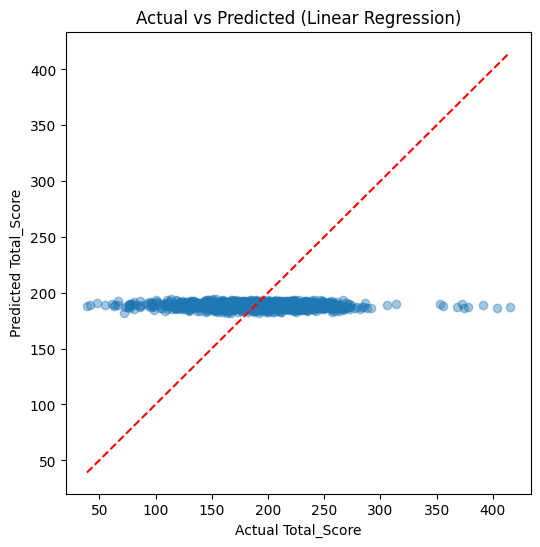

In [ ]:
# Actual vs Predicted plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Total_Score')
plt.ylabel('Predicted Total_Score')
plt.title('Actual vs Predicted (Linear Regression)')
plt.show()

In [ ]:
# Coefficient interpretation
coef_df = pd.DataFrame({'Feature': X_lin.columns, 'Coefficient': lin_model.coef_})
coef_df.sort_values('Coefficient', ascending=False)

,Feature,Coefficient
4,Gender_other,0.926032
25,Internet_Access_Yes,0.730603
3,Gender_male,0.424729
22,Parent_Education_Primary,0.411851
19,Parent_Education_Illiterate,0.342147
0,Age,0.318182
18,Parent_Education_Higher Secondary,0.199948
1,Attendance_Percentage,0.029518
14,Class_6,0.028269
23,Parent_Education_Secondary,0.004422


# Part D — Logistic Regression
Target: Result (pass = 1, fail = 0)

In [ ]:
df1["Result"] = df1["Result"].replace({
    "F": "Fail",
    "FAIL":"Fail",
    "fail":"Fail",
    "PASS":"Pass",
    "P":"Pass",
    "pass":"Pass"
})
df1["Result"].unique()

array([0, 1])

In [ ]:
print(df1["Result"].unique())

[0 1]


In [ ]:
# Target
y_log = df1["Result"]

# Features
drop_for_log = ["Student_ID", "Name", "Result"]
X_log = df1_encoded.drop(columns=drop_for_log, errors="ignore")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_log,
    y_log,
    test_size=0.2,
    random_state=42,
    stratify=y_log
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# Prediction
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.612
Precision: 0.44680851063829785
Recall: 0.22826086956521738
F1 Score: 0.302158273381295
ROC-AUC: 0.6219063875894332


In [ ]:
print(df1["Result"].value_counts())

Result
0    6321
1    3679
Name: count, dtype: int64


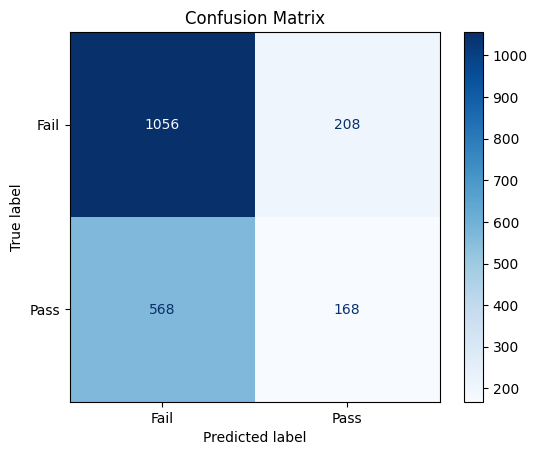

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Fail','Pass']).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

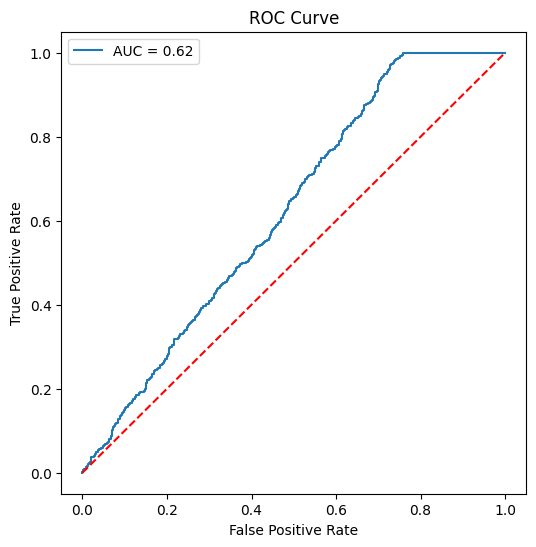

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.2f}')
plt.plot([0,1], [0,1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
# Class balance check
df['Result'].value_counts(normalize=True)

,proportion
Result,
Fail,0.132626
P,0.126924
fail,0.125898
FAIL,0.125328
pass,0.124758
F,0.122819
Pass,0.122249
PASS,0.119398


In [ ]:
print(df1["Result"].unique())

print(df1["Result"].value_counts())

print(df1["Result"].dtype)

[0 1]
Result
0    6321
1    3679
Name: count, dtype: int64
int64
